# Week 8 Activity: Onset Detection and Autocorrelation

Complete this activity as part of your participation grade. Pending length of the lecture, you will have time in class to work. Everything you need to complete this activity can be found in this week's (or a previous week's) lecture code.

## Onset Detection

Read in the following files below, and normalize.

a) 80sPopDrums.wav  
b) TheBlackKeys_track4.wav (use random 10s from near middle of track)  
c) prelude_cmaj_10s.wav  

In [149]:
import numpy as np
import scipy
from scipy.io.wavfile import read
from scipy import signal
import matplotlib.pyplot as plt
from IPython.display import Audio
import librosa, librosa.display
from collections import Counter
(fs, x1) = read('../audio/80sPopDrums.wav')
(fs, x2) = read('../audio/TheBlackKeys_track4.wav')
(fs, x3) = read('../audio/prelude_cmaj_10s.wav')
#all files have same fs

x1 = x1/abs(x1.max())
x2 = x2/abs(x2.max())
x3 = x3[:,0]/abs(x3.max()) #left channel of stereo

Audio(x1, rate = fs)


#### For each of the tracks (start with just one):

1) Compute the energy and RMSE for each track using a frame length of your choice  
2) Plot the energy and the RMSE
3) Use one of the energy features to create your novelty function and plot
4) Write a peak picking function to define onsets from your novelty function
4) Based on the plots, estimate what an appropriate 'threshold' would be. Does the threshold change across tracks? If so, what could you do to put them on a similar scale?

a) 80's pop drums

<function matplotlib.pyplot.legend(*args, **kwargs)>

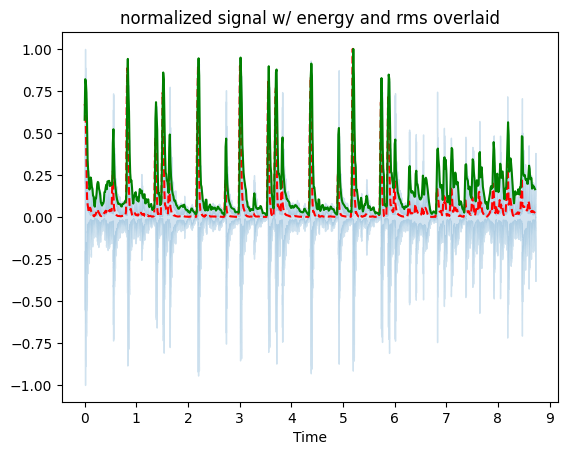

In [133]:
hop_length = 512
frame_length = 1024

energy1 = np.array([
        sum(abs(x1[i:i+frame_length]**2)) for i in range(0, len(x1), hop_length)
    ])

#rmse
rmse1 = librosa.feature.rms(y = x1, frame_length=frame_length, hop_length=hop_length, center=True)

#plotting
frames1 = range(len(energy))
t1 = librosa.frames_to_time(frames1, sr = fs, hop_length=hop_length)
librosa.display.waveshow(x1, sr=fs, alpha=0.2)
plt.plot(t1, energy1/energy1.max(), 'r--', label = 'energy')
plt.plot(t1, rmse1[0]/rmse1[0].max(), 'g', label = 'rmse')
plt.title('normalized signal w/ energy and rms overlaid')
plt.legend

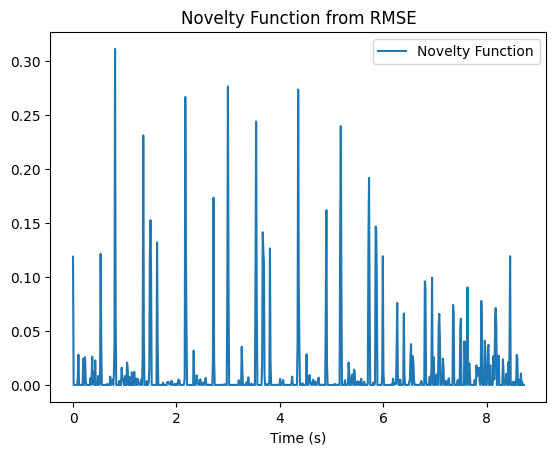

In [134]:
novelty1 = np.concatenate((np.diff(rmse1[0]), np.array([0])))
novelty1[novelty1 < 0] = 0
plt.plot(t1, novelty1, label='Novelty Function')
plt.xlabel('Time (s)')
plt.title('Novelty Function from RMSE')
plt.legend()
plt.show()

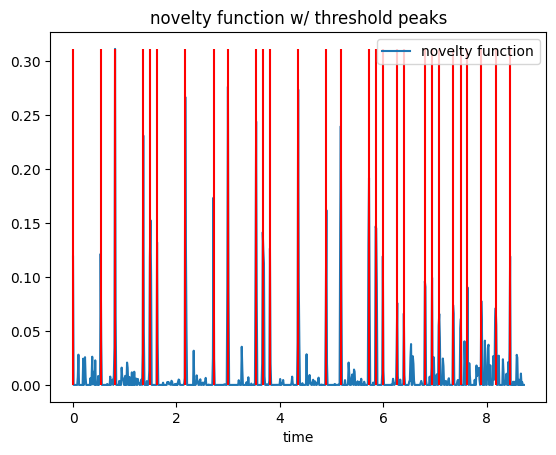

In [135]:
threshold = 0.05
peak_indices = []

for i in range(0, len(novelty1)):
    if novelty1[i] > threshold:
        if novelty1[i] > novelty1[i-1] and novelty1[i] > novelty1[i+1]:
            peak_indices.append(i)

peak_indices = np.array(peak_indices)
peak_times1 = t1[peak_indices]

plt.plot(t1, novelty1, label = 'novelty function')
plt.vlines(peak_times1, 0, np.max(novelty1), colors='r')
plt.xlabel('time')
plt.title('novelty function w/ threshold peaks')
plt.legend()
plt.show()

b) the black keys - track 4

<function matplotlib.pyplot.legend(*args, **kwargs)>

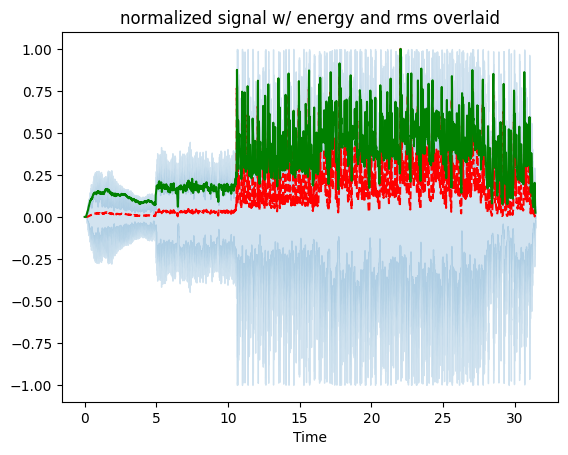

In [136]:
hop_length = 512
frame_length = 1024

energy2 = np.array([
        sum(abs(x2[i:i+frame_length]**2)) for i in range(0, len(x2), hop_length)
    ])

#rmse
rmse2 = librosa.feature.rms(y = x2, frame_length=frame_length, hop_length=hop_length, center=True)

#plotting
frames2 = range(len(energy2))
t2 = librosa.frames_to_time(frames2, sr = fs, hop_length=hop_length)
librosa.display.waveshow(x2, sr=fs, alpha=0.2)
plt.plot(t2, energy2/energy2.max(), 'r--', label = 'energy')
plt.plot(t2, rmse2[0]/rmse2[0].max(), 'g', label = 'rmse')
plt.title('normalized signal w/ energy and rms overlaid')
plt.legend

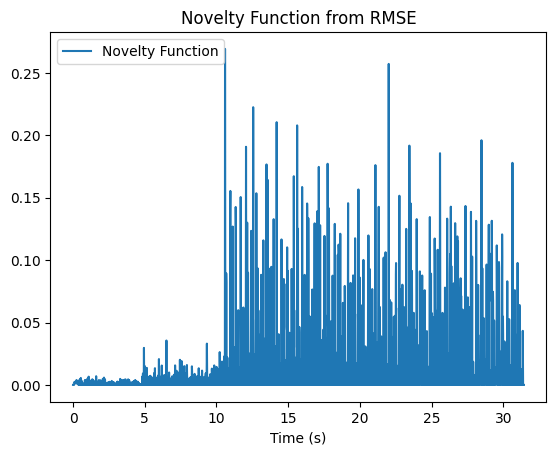

In [137]:
novelty2 = np.concatenate((np.diff(rmse2[0]), np.array([0])))
novelty2[novelty2 < 0] = 0
plt.plot(t2, novelty2, label='Novelty Function')
plt.xlabel('Time (s)')
plt.title('Novelty Function from RMSE')
plt.legend()
plt.show()

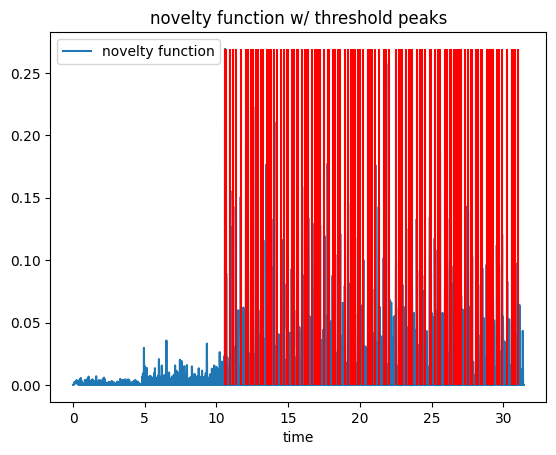

In [139]:
threshold = 0.07
peak_indices = []

for i in range(0, len(novelty2)):
    if novelty2[i] > threshold:
        if novelty2[i] > novelty2[i-1] and novelty2[i] > novelty2[i+1]:
            peak_indices.append(i)

peak_indices = np.array(peak_indices)
peak_times2 = t2[peak_indices]

plt.plot(t2, novelty2, label = 'novelty function')
plt.vlines(peak_times2, 0, np.max(novelty2), colors='r')
plt.xlabel('time')
plt.title('novelty function w/ threshold peaks')
plt.legend()
plt.show()

c) prelude

<function matplotlib.pyplot.legend(*args, **kwargs)>

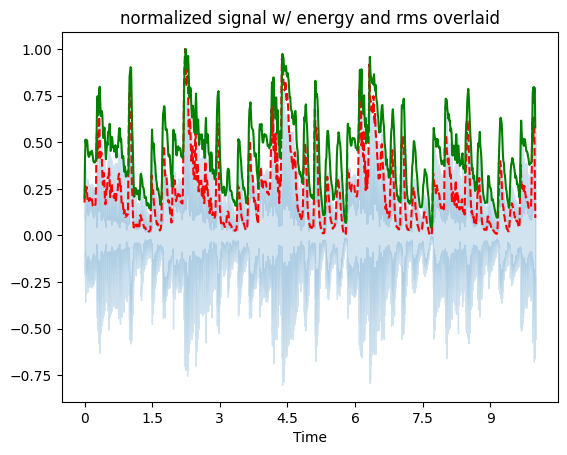

In [140]:
hop_length = 512
frame_length = 1024

energy3 = np.array([
        sum(abs(x3[i:i+frame_length]**2)) for i in range(0, len(x3), hop_length)
    ])

#rmse
rmse3 = librosa.feature.rms(y = x3, frame_length=frame_length, hop_length=hop_length, center=True)

#plotting
frames3 = range(len(energy3))
t3 = librosa.frames_to_time(frames3, sr = fs, hop_length=hop_length)
librosa.display.waveshow(x3, sr=fs, alpha=0.2)
plt.plot(t3, energy3/energy3.max(), 'r--', label = 'energy')
plt.plot(t3, rmse3[0]/rmse3[0].max(), 'g', label = 'rmse')
plt.title('normalized signal w/ energy and rms overlaid')
plt.legend

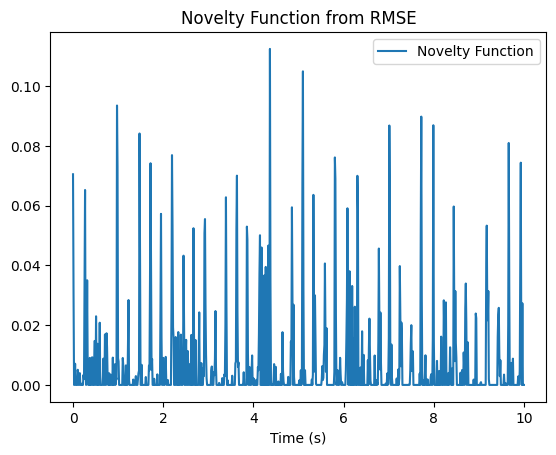

In [141]:
novelty3 = np.concatenate((np.diff(rmse3[0]), np.array([0])))
novelty3[novelty3 < 0] = 0
plt.plot(t3, novelty3, label='Novelty Function')
plt.xlabel('Time (s)')
plt.title('Novelty Function from RMSE')
plt.legend()
plt.show()

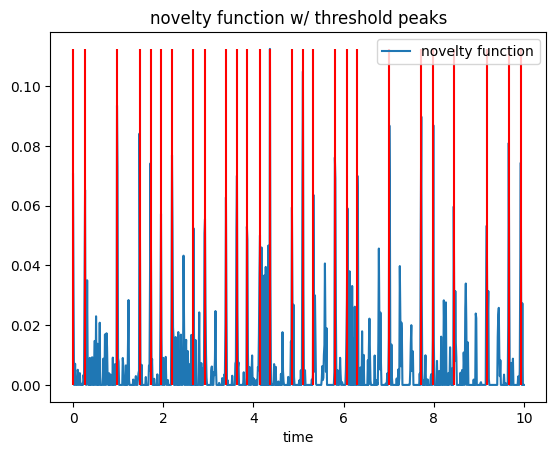

In [143]:
threshold = 0.05
peak_indices = []

for i in range(0, len(novelty3)):
    if novelty3[i] > threshold:
        if novelty3[i] > novelty3[i-1] and novelty3[i] > novelty3[i+1]:
            peak_indices.append(i)

peak_indices = np.array(peak_indices)
peak_times3 = t3[peak_indices]

plt.plot(t3, novelty3, label = 'novelty function')
plt.vlines(peak_times3, 0, np.max(novelty3), colors='r')
plt.xlabel('time')
plt.title('novelty function w/ threshold peaks')
plt.legend()
plt.show()

Based on the plots, the threshold changes across tracks. Visually, I picked out 0.05, 0.07, and 0.05 as good estimates for each of the tracks respectively to accurately capture the peaks. One way to 'normalize' this across any track would be to do it based on genre and determine on average the amount of peaks tracks have per __ seconds, then to iteratively keep decreasing/increasing the threshold until said peaks are in range.

## Tempo Estimation

Using your novelty functions and detected onsets above, estimate the global tempo of the files using autocorrelation and IOIs.

1) IOI Based Tempo

- Compute Inter-Onset Intervals (IOIs)
- Convert IOIs to BPM
- Create a beat histogram to help you infer tempos

a) 80s pop drums

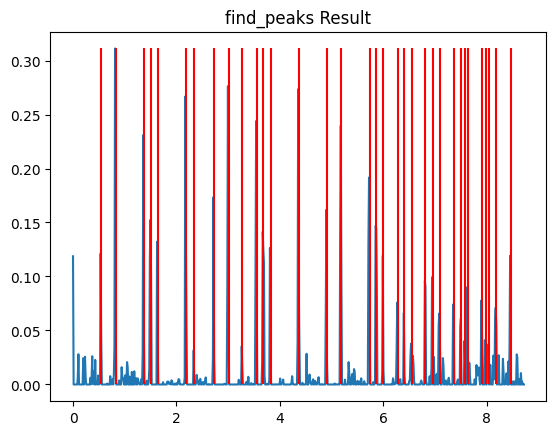

[(215.0, 7), (110.0, 4), (431.0, 2)]

In [185]:
frames1 = range(len(novelty1))
t1_1 = librosa.frames_to_time(frames1, sr = fs, hop_length=hop_length)
# plt.figure(figsize=(14,4))
# plt.plot(t1_1, novelty1/novelty1.max(), label='Normalized Novelty')
# plt.legend()
# plt.title('Novelty')
# plt.show()

peaks1, properties1 = signal.find_peaks(novelty1, height = 0.03)

peak_times1_1 = t1_1[1:][peaks1]
plt.plot(t1_1, novelty1)
plt.vlines(peak_times1_1, 0, np.max(novelty1), colors='r')
plt.title('find_peaks Result')
plt.show()

iois1 = np.diff(peak_times1_1)
counter1 = Counter(iois1)
most_repeated = counter1.most_common(25)
valid_tempos = []
for i in most_repeated:
    tempo = 60 / i[0]
    if tempo > 300:
        tempo = tempo / 2
    elif tempo < 40:
        tempo = tempo * 2
    valid_tempos.append(round(tempo,0))

counter1_1 = Counter(valid_tempos)
common_tempo = counter1_1.most_common(3)
common_tempo

Text(0.5, 1.0, 'beat historgram (iois)')

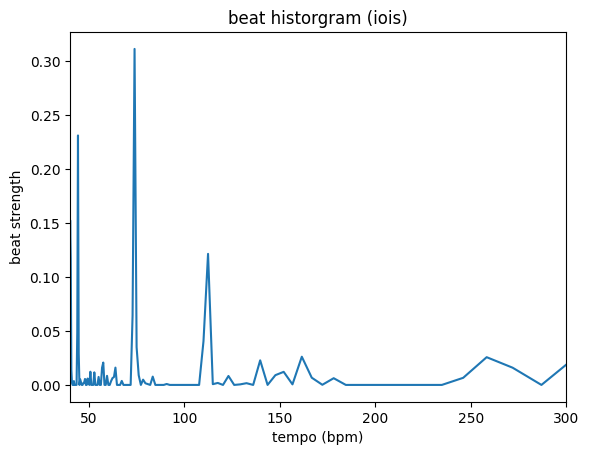

In [201]:
frame_times1 = np.arange(len(frames1)) * hop_length / fs
bpms = 60 / frame_times1[1:]
strength = novelty1[1:]
plt.plot(bpms, strength)
plt.xlim(40,300)
plt.xlabel("tempo (bpm)")
plt.ylabel('beat strength')
plt.title("beat historgram (iois)")


b) black keys

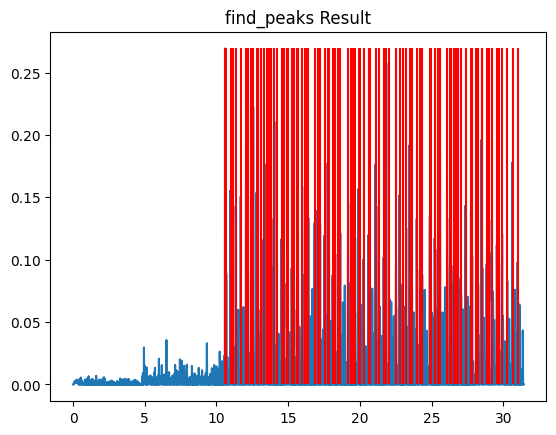

[(199.0, 3), (172.0, 2), (185.0, 1)]

In [180]:
frames2 = range(len(novelty2))
t2_1 = librosa.frames_to_time(frames2, sr = fs, hop_length=hop_length)
# plt.figure(figsize=(14,4))
# plt.plot(t2_1, novelty2/novelty2.max(), label='Normalized Novelty')
# plt.legend()
# plt.title('Novelty')
# plt.show()

peaks2, properties2 = signal.find_peaks(novelty2, height = 0.08)

peak_times2_1 = t2_1[1:][peaks2]
plt.plot(t2_1, novelty2)
plt.vlines(peak_times2_1, 0, np.max(novelty2), colors='r')
plt.title('find_peaks Result')
plt.show()

iois2 = np.diff(peak_times2_1)
counter2 = Counter(iois2)
most_repeated = counter2.most_common(25)
valid_tempos = []
for i in most_repeated:
    tempo = 60 / i[0]
    if tempo > 300:
        tempo = tempo / 2
    elif tempo < 40:
        tempo = tempo * 2
    if tempo < 250 and tempo > 40:
        valid_tempos.append(round(tempo,0))

valid_tempos
counter2_1 = Counter(valid_tempos)
common_tempo = counter2_1.most_common(3)
common_tempo

Text(0.5, 1.0, 'beat historgram (iois)')

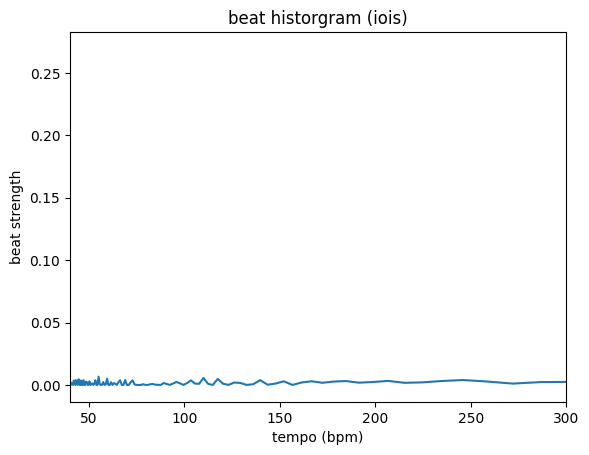

In [202]:
frame_times2 = np.arange(len(frames2)) * hop_length / fs
bpms = 60 / frame_times2[1:]
strength = novelty2[1:]
plt.plot(bpms, strength)
plt.xlim(40,300)
plt.xlabel("tempo (bpm)")
plt.ylabel('beat strength')
plt.title("beat historgram (iois)")

c) prelude

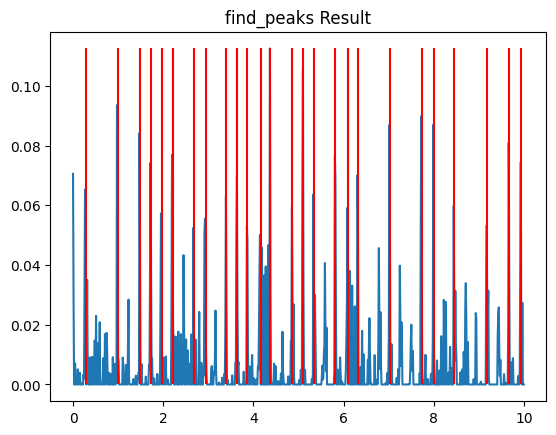

[(246.0, 3), (85.0, 2), (123.0, 2)]

In [182]:
frames3 = range(len(novelty3))
t3_1 = librosa.frames_to_time(frames3, sr = fs, hop_length=hop_length)
# plt.figure(figsize=(14,4))
# plt.plot(t3_1, novelty3/novelty3.max(), label='Normalized Novelty')
# plt.legend()
# plt.title('Novelty')
# plt.show()

peaks3, properties3 = signal.find_peaks(novelty3, height = 0.05)

peak_times3_1 = t3_1[1:][peaks3]
plt.plot(t3_1, novelty3)
plt.vlines(peak_times3_1, 0, np.max(novelty3), colors='r')
plt.title('find_peaks Result')
plt.show()

iois3 = np.diff(peak_times3_1)
counter3 = Counter(iois3)
most_repeated = counter3.most_common(25)
valid_tempos = []
for i in most_repeated:
    tempo = 60 / i[0]
    if tempo > 300:
        tempo = tempo / 2
    elif tempo < 40:
        tempo = tempo * 2
    if tempo < 250 and tempo > 40:
        valid_tempos.append(round(tempo,0))

valid_tempos
counter3_1 = Counter(valid_tempos)
common_tempo = counter3_1.most_common(3)
common_tempo

Text(0.5, 1.0, 'beat historgram (iois)')

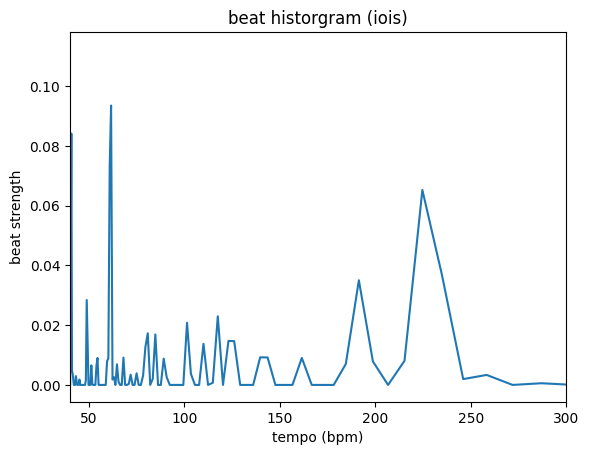

In [203]:
frame_times3 = np.arange(len(frames3)) * hop_length / fs
bpms = 60 / frame_times3[1:]
strength = novelty3[1:]
plt.plot(bpms, strength)
plt.xlim(40,300)
plt.xlabel("tempo (bpm)")
plt.ylabel('beat strength')
plt.title("beat historgram (iois)")

2) Autocorrelation based Tempo
- Compute the autocorrelation of your novelty function
- Convert lag to BPMs (conside perceptual relevance)
- Crate a beat histogram to help you infer tempos

a) 80s pop drums

[(112.0, 1), (225.0, 1), (110.0, 1)]

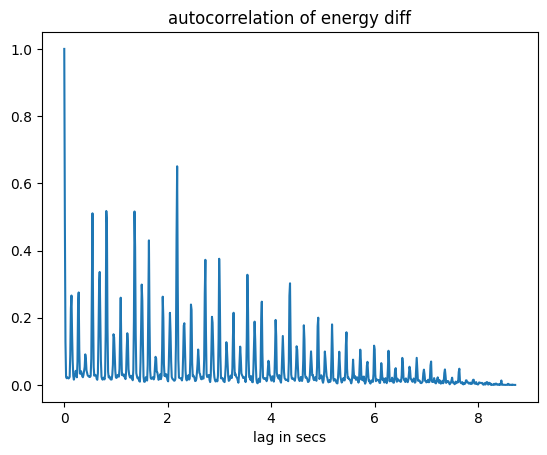

In [222]:
ac1 = librosa.autocorrelate(novelty1)
ac1 = ac1 / ac1.max()

# plt.figure(figsize=(12,5))
# plt.plot(ac1)
# plt.title('autocorrelation of energy diff')
# plt.xlabel('time lag')

lags = np.arange(len(ac1))
plt.plot(lags * hop_length / fs, ac1)
plt.xlabel("lag in secs")
plt.title("autocorrelation of energy diff")

points = np.array(np.where(ac1 > 0.3))
t_ac1 = hop_length * points / fs
t_ac1_list = t_ac1[0][2:]
durs1 = t_ac1_list[1:] - t_ac1_list[:-1]
durs1 = np.round(durs1, 3)

counter_ac1 = Counter(durs1)
ac_repeats = counter_ac1.most_common(10)
valid_tempos1 = []
for i in ac_repeats:
    tempo = 60 / i[0]
    if tempo > 300:
        tempo = tempo / 2
    elif tempo < 40:
        tempo = tempo * 2
    if tempo < 250 and tempo > 40:
        valid_tempos1.append(round(tempo,0))

actempo_counter = Counter(valid_tempos1)
common_tempo1 = actempo_counter.most_common(3)
common_tempo1

Text(0.5, 1.0, 'Beat Histogram (Autocorrelation)')

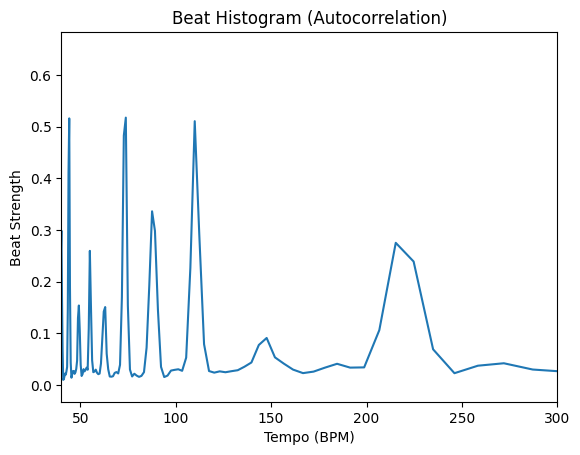

In [223]:
lag_times1 = lags * hop_length / fs
bpms = 60 / lag_times1[1:]
strength = ac1[1:]
plt.plot(bpms, strength)
plt.xlim(40, 300)
plt.xlabel("Tempo (BPM)")
plt.ylabel("Beat Strength")
plt.title("Beat Histogram (Autocorrelation)")

b) black keys - track 4

[(178.0, 1), (86.0, 1), (85.0, 1)]

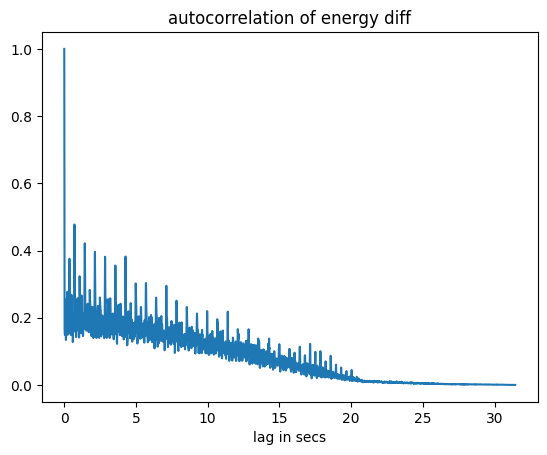

In [224]:
ac2 = librosa.autocorrelate(novelty2)
ac2 = ac2 / ac2.max()

# plt.figure(figsize=(12,5))
# plt.plot(ac2)
# plt.title('autocorrelation of energy diff')
# plt.xlabel('time lag')

lags = np.arange(len(ac2))
plt.plot(lags * hop_length / fs, ac2)
plt.xlabel("lag in secs")
plt.title("autocorrelation of energy diff")

points = np.array(np.where(ac2 > 0.3))
t_ac2 = hop_length * points / fs
t_ac2_list = t_ac2[0][2:]
durs2 = t_ac2_list[1:] - t_ac2_list[:-1]
durs2 = np.round(durs2, 3)

counter_ac2 = Counter(durs2)
ac_repeats = counter_ac2.most_common(10)
valid_tempos2 = []
for i in ac_repeats:
    tempo = 60 / i[0]
    if tempo > 300:
        tempo = tempo / 2
    elif tempo < 40:
        tempo = tempo * 2
    if tempo < 250 and tempo > 40:
        valid_tempos2.append(round(tempo,0))

actempo_counter = Counter(valid_tempos2)
common_tempo2 = actempo_counter.most_common(3)
common_tempo2

Text(0.5, 1.0, 'Beat Histogram (Autocorrelation)')

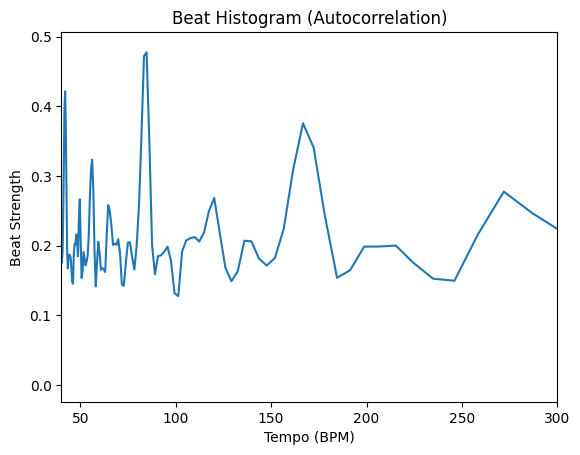

In [225]:
lag_times2 = lags * hop_length / fs
bpms = 60 / lag_times2[1:]
strength = ac2[1:]
plt.plot(bpms, strength)
plt.xlim(40, 300)
plt.xlabel("Tempo (BPM)")
plt.ylabel("Beat Strength")
plt.title("Beat Histogram (Autocorrelation)")

c) prelude

[(123.0, 1), (235.0, 1)]

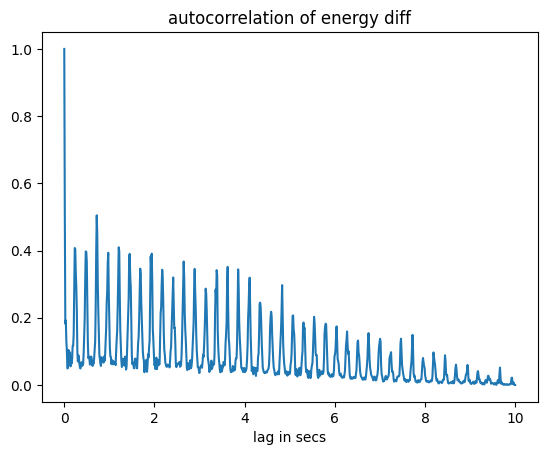

In [231]:
ac3 = librosa.autocorrelate(novelty3)
ac3 = ac3 / ac3.max()

# plt.figure(figsize=(12,5))
# plt.plot(ac3)
# plt.title('autocorrelation of energy diff')
# plt.xlabel('time lag')

lags = np.arange(len(ac3))
plt.plot(lags * hop_length / fs, ac3)
plt.xlabel("lag in secs")
plt.title("autocorrelation of energy diff")

points = np.array(np.where(ac3 > 0.3))
t_ac3 = hop_length * points / fs
t_ac3_list = t_ac3[0][2:]
durs3 = t_ac3_list[1:] - t_ac3_list[:-1]
durs3 = np.round(durs3, 3)

counter_ac3 = Counter(durs3)
ac_repeats = counter_ac3.most_common(10)
valid_tempos3 = []
for i in ac_repeats:
    tempo = 60 / i[0]
    if tempo > 300:
        tempo = tempo / 2
    elif tempo < 40:
        tempo = tempo * 2
    if tempo < 250 and tempo > 40:
        valid_tempos3.append(round(tempo,0))

actempo_counter = Counter(valid_tempos3)
common_tempo3 = actempo_counter.most_common(3)
common_tempo3

Text(0.5, 1.0, 'Beat Histogram (Autocorrelation)')

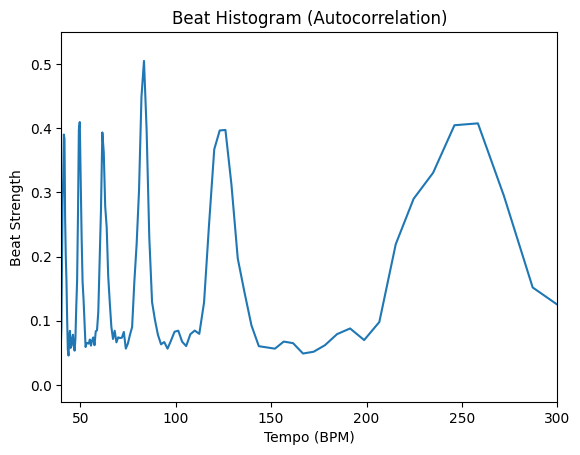

In [230]:
lag_times3 = lags * hop_length / fs
bpms = 60 / lag_times3[1:]
strength = ac3[1:]
plt.plot(bpms, strength)
plt.xlim(40, 300)
plt.xlabel("Tempo (BPM)")
plt.ylabel("Beat Strength")
plt.title("Beat Histogram (Autocorrelation)")


Estimate tempo using librosa.beat.tempo. How do your results compare?

Between autocorrelation and IOIs, which method is most stable? Which is most sensitive to onset errors Do the different files present different behaviors/accuracies?

## Extension

Repeat the activities above but change the frame size and hop length. How does that impact your results?